# Lista 1 - Regressão Linear: OLS, GD e SGD

**Aluno:** Diego Melo do Nascimento  
**Matrícula:** 603127


In [359]:
import numpy as np
import matplotlib.pyplot as plt

In [360]:
# Funções utilitárias
def mean(x):
    return x.sum(axis=0) / x.shape[0]

def std(x):
    mi = mean(x)
    n = x.shape[0]
    return (np.sum((x - mi) ** 2, axis=0) / n) ** 0.5

def normalize_zscore(x):
    mi = mean(x)
    std_ = std(x)
    params = (mi, std_)
    return (x - mi) / std_, params

def denormalize_zscore(x, params):
    mi, std_ = params
    return x * std_ + mi

def mse(y, y_pred):
    """Erro quadrático médio"""
    return mean((y - y_pred) ** 2)

def rmse(y, y_pred):
    """Raíz do erro quadrático médio"""
    return mse(y, y_pred) ** 0.5

## Questão 1

In [361]:
data = np.genfromtxt('data/artificial1d.csv', delimiter=',')

In [362]:
X_raw = data[:, [0]]  # Coluna x
y_raw = data[:, [1]]  # Coluna y
print(f"Dados carregados: {X_raw.shape[0]} amostras")
print(f"X shape: {X_raw.shape}, y shape: {y_raw.shape}")

Dados carregados: 30 amostras
X shape: (30, 1), y shape: (30, 1)


In [363]:
def gradient_descent(X, y, alpha=0.01, epochs=1000, batch_size=None, tol=1e-8):
    """
    Gradiente Descendente Genérico (Batch ou Estocástico)
    """
    N = X.shape[0]
    n_features = X.shape[1]
    w = np.zeros((n_features, 1))
    errors = []
    
    # Se batch_size não é especificado, usar GD (batch completo)
    batch_size = batch_size or N
    
    for epoch in range(epochs):
        indices = np.arange(N)
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Processar em lotes
        for i in range(0, N, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # Calcular predições e erros do lote
            y_pred_batch = X_batch @ w
            e_batch = y_batch - y_pred_batch
            
            # Atualizar pesos: w ← w + (α/batch_size) * X^T @ e
            w = w + (alpha / batch_size) * (X_batch.T @ e_batch)
        
        # Calcular erro total para critério de convergência
        y_pred = X @ w
        error = mse(y, y_pred)
        errors.append(error)
        
        if error < tol:
            break
    
    y_pred = X @ w
    return w, y_pred, errors


def ols(X, y):
    """ Mínimos Quadrados Ordinários (Ordinary Least Squares) """
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    y_pred = X @ w
    return w, y_pred


def gd(X, y, alpha=0.01, epochs=1000, tol=1e-8):
    """ Gradiente Descendente (GD)"""
    return gradient_descent(X, y, alpha=alpha, epochs=epochs, batch_size=X.shape[0], tol=tol)


def sgd(X, y, alpha=0.01, epochs=1000, tol=1e-8):
    """ Gradiente Descendente Estocástico (SGD)"""
    return gradient_descent(X, y, alpha=alpha, epochs=epochs, batch_size=1, tol=tol)


In [364]:
[i for i in range(0, 10, 10)]

[0]

## a) OLS (Ordinary Least Squares)

In [365]:
# Preparar dados para OLS
X_norm, X_params = normalize_zscore(X_raw)
y_norm, y_params = normalize_zscore(y_raw)

In [366]:
# Adicionar coluna de 1s (bias)
X_ols = np.c_[np.ones((X_raw.shape[0], 1)), X_norm]

In [367]:
# Executar OLS
w_ols, y_pred_norm = ols(X_ols, y_norm)

In [368]:
# Desnormalizar predições
y_pred_ols = denormalize_zscore(y_pred_norm, y_params)

In [369]:
# Calcular métrica
mse_ols = float(mse(y_raw, y_pred_ols).item())

In [370]:
print("=" * 60)
print("a) OLS (Ordinary Least Squares)")
print("=" * 60)
print(f"Parâmetros w: {w_ols.T[0]}")
print(f"w0 (bias): {w_ols[0, 0]:.6f}")
print(f"w1 (coef): {w_ols[1, 0]:.6f}")
print(f"MSE: {mse_ols:.6f}")
print()

a) OLS (Ordinary Least Squares)
Parâmetros w: [-1.38777878e-17  8.97493907e-01]
w0 (bias): -0.000000
w1 (coef): 0.897494
MSE: 0.213401



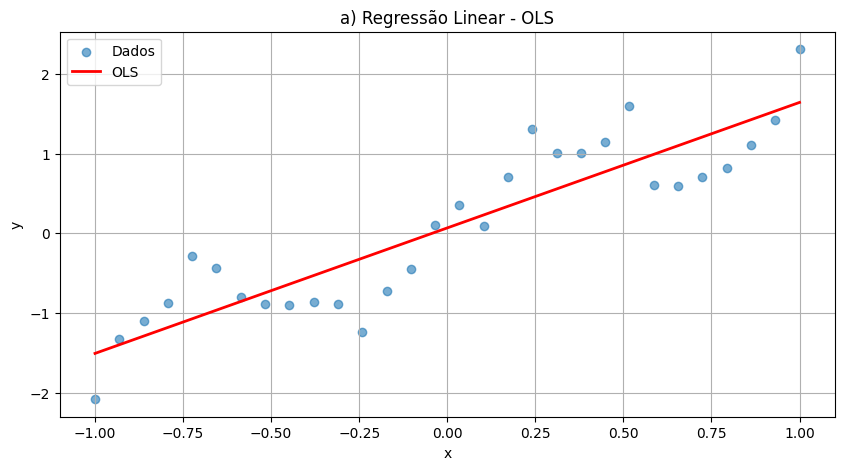

In [371]:
# Plotar resultado OLS
plt.figure(figsize=(10, 5))
plt.scatter(X_raw, y_raw, alpha=0.6, label='Dados')
plt.plot(X_raw, y_pred_ols, 'r-', linewidth=2, label='OLS')
plt.xlabel('x')
plt.ylabel('y')
plt.title('a) Regressão Linear - OLS')
plt.legend()
plt.grid(True)
plt.show()

## b) GD (Gradient Descent)

In [372]:
# Preparar dados para GD
X_norm, X_params = normalize_zscore(X_raw)
y_norm, y_params = normalize_zscore(y_raw)

In [373]:
# Adicionar coluna de 1s (bias)
X_gd = np.c_[np.ones((X_raw.shape[0], 1)), X_norm]

In [374]:
# batch_size = N (todos os dados)
w_gd, y_pred_norm_gd, errors_gd = gd(
    X_gd, y_norm,
    alpha=0.01, 
    epochs=1000
)

In [375]:
# Desnormalizar predições
y_pred_gd = denormalize_zscore(y_pred_norm_gd, y_params)

In [376]:
# Calcular MSE
mse_gd = float(mse(y_raw, y_pred_gd).item())

In [377]:
print("=" * 60)
print("b) GD (Gradient Descent)")
print("=" * 60)
print(f"Parâmetros w: {w_gd.T[0]}")
print(f"w0 (bias): {w_gd[0, 0]:.6f}")
print(f"w1 (coef): {w_gd[1, 0]:.6f}")
print(f"MSE: {mse_gd:.6f}")
print(f"Número de épocas convergidas: {len(errors_gd)}")
print()

b) GD (Gradient Descent)
Parâmetros w: [-5.53943465e-17  8.97455161e-01]
w0 (bias): -0.000000
w1 (coef): 0.897455
MSE: 0.213401
Número de épocas convergidas: 1000



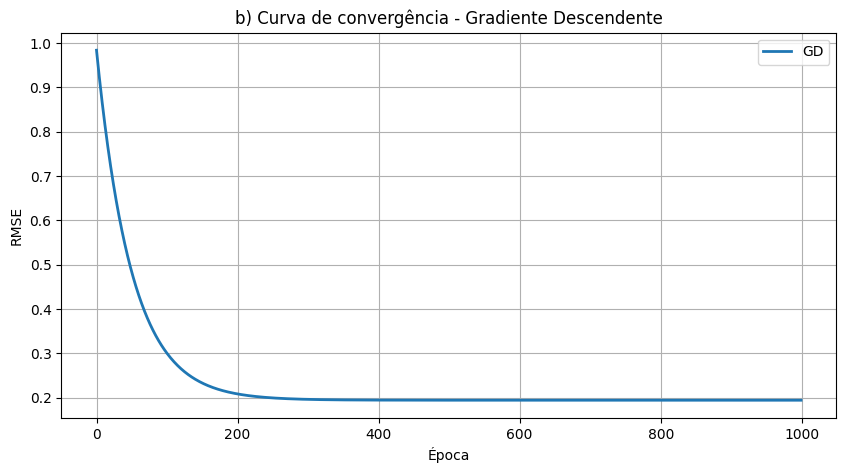

In [378]:
# Plotar curva de aprendizagem de GD
plt.figure(figsize=(10, 5))
plt.plot(errors_gd, linewidth=2, label='GD')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.title('b) Curva de convergência - Gradiente Descendente')
plt.legend()
plt.grid(True)
plt.show()

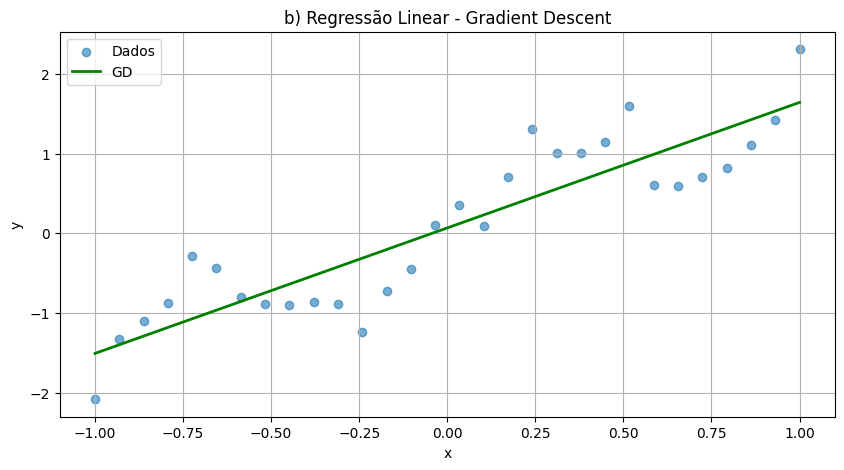

In [379]:
# Plotar reta resultante de GD
plt.figure(figsize=(10, 5))
plt.scatter(X_raw, y_raw, alpha=0.6, label='Dados')
plt.plot(X_raw, y_pred_gd, 'g-', linewidth=2, label='GD')
plt.xlabel('x')
plt.ylabel('y')
plt.title('b) Regressão Linear - Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

## c) SGD (Stochastic Gradient Descent)

In [380]:
# Preparar dados para SGD
X_norm, X_params = normalize_zscore(X_raw)
y_norm, y_params = normalize_zscore(y_raw)

In [381]:
# Adicionar coluna de 1s (bias)
X_sgd = np.c_[np.ones((X_raw.shape[0], 1)), X_norm]

In [382]:
# batch_size = 1 (um dado por vez)
w_sgd, y_pred_norm_sgd, errors_sgd = sgd(
    X_sgd, y_norm,
    alpha=0.01, 
    epochs=1000
)

In [383]:
# Desnormalizar predições
y_pred_sgd = denormalize_zscore(y_pred_norm_sgd, y_params)

In [384]:
# Calcular MSE
mse_sgd = float(mse(y_raw, y_pred_sgd).item())

In [385]:
print("=" * 60)
print("c) SGD (Stochastic Gradient Descent)")
print("=" * 60)
print(f"Parâmetros w: {w_sgd.T[0]}")
print(f"w0 (bias): {w_sgd[0, 0]:.6f}")
print(f"w1 (coef): {w_sgd[1, 0]:.6f}")
print(f"MSE: {mse_sgd:.6f}")
print(f"Número de épocas convergidas: {len(errors_sgd)}")
print()

c) SGD (Stochastic Gradient Descent)
Parâmetros w: [-0.00175331  0.89594793]
w0 (bias): -0.001753
w1 (coef): 0.895948
MSE: 0.213407
Número de épocas convergidas: 1000



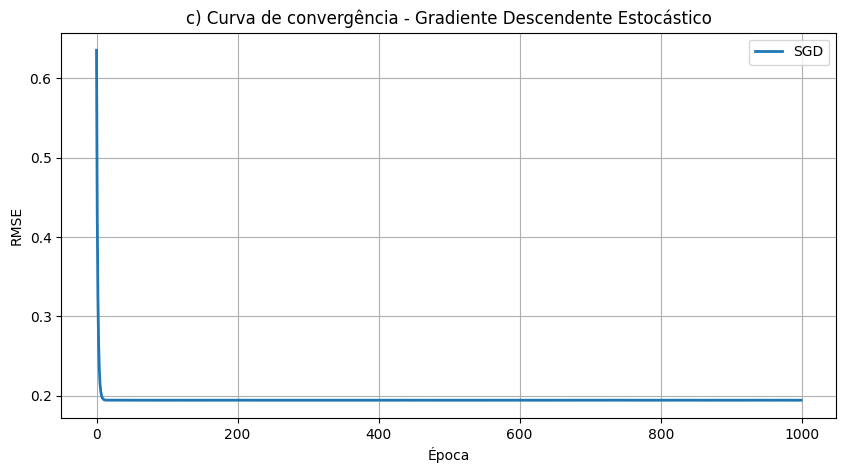

In [386]:
# Plotar curva de aprendizagem de SGD
plt.figure(figsize=(10, 5))
plt.plot(errors_sgd, linewidth=2, label='SGD')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.title('c) Curva de convergência - Gradiente Descendente Estocástico')
plt.legend()
plt.grid(True)
plt.show()

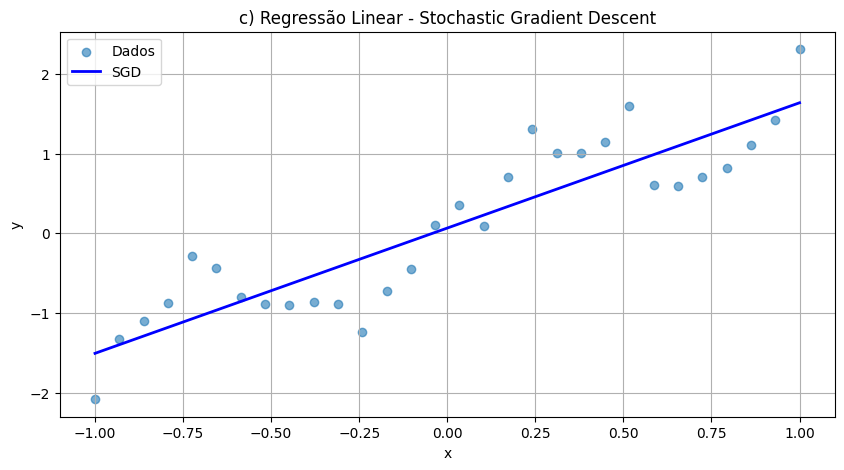

In [387]:
# Plotar reta resultante de SGD
plt.figure(figsize=(10, 5))
plt.scatter(X_raw, y_raw, alpha=0.6, label='Dados')
plt.plot(X_raw, y_pred_sgd, 'b-', linewidth=2, label='SGD')
plt.xlabel('x')
plt.ylabel('y')
plt.title('c) Regressão Linear - Stochastic Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

In [388]:
# Resumo comparativo dos três algoritmos
print("\nRESUMO COMPARATIVO - QUESTÃO 1")
print(f"OLS:   w0={w_ols[0,0]:.6f}, w1={w_ols[1,0]:.6f}, MSE={mse_ols:.6f}")
print(f"GD:    w0={w_gd[0,0]:.6f}, w1={w_gd[1,0]:.6f}, MSE={mse_gd:.6f}")
print(f"SGD:   w0={w_sgd[0,0]:.6f}, w1={w_sgd[1,0]:.6f}, MSE={mse_sgd:.6f}")
print(f"\nConvergência: Diferença máxima OLS-GD = {abs(w_ols[1,0] - w_gd[1,0]):.2e}")
print(f"Diferença máxima entre OLS e SGD: {abs(w_ols[1,0] - w_sgd[1,0]):.2e}")


RESUMO COMPARATIVO - QUESTÃO 1
OLS:   w0=-0.000000, w1=0.897494, MSE=0.213401
GD:    w0=-0.000000, w1=0.897455, MSE=0.213401
SGD:   w0=-0.001753, w1=0.895948, MSE=0.213407

Convergência: Diferença máxima OLS-GD = 3.87e-05
Diferença máxima entre OLS e SGD: 1.55e-03


# Questão 2 - Regressão Polinomial com California Housing

In [389]:
# Carregar dados do California Housing
data_california = np.genfromtxt('data/california.csv', delimiter=',', skip_header=1)
print(f"Shape dos dados: {data_california.shape}")

Shape dos dados: (999, 9)


In [390]:
# Separar features (X) e target (y)
X_california = data_california[:, :-1]  # Primeiras 8 colunas
y_california = data_california[:, -1:]  # Última coluna

In [391]:
print(f"\nX shape: {X_california.shape}, y shape: {y_california.shape}")


X shape: (999, 8), y shape: (999, 1)


In [392]:
def normalize_minmax(x):
    x_min = x.min(axis=0)
    x_max = x.max(axis=0)
    params = (x_min, x_max)
    return (x - x_min) / (x_max - x_min + 1e-8), params

def denormalize_minmax(x, params):
    x_min, x_max = params
    return x * (x_max - x_min) + x_min

def polynomial_features(X, degree):
    n_samples, n_features = X.shape
    features = [np.ones((n_samples, 1))]  
    for d in range(1, degree + 1):
        for i in range(n_features):
            features.append(X[:, i:i+1] ** d)
    return np.hstack(features)

def ols_ridge(X, y, lambda_reg=0):
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0  # Não regularizar o bias
    w = np.linalg.inv(X.T @ X + lambda_reg * I) @ X.T @ y
    y_pred = X @ w
    return w, y_pred

## a) Divisão em Treino (80%) e Teste (20%)

In [393]:
# Divisão treino/teste (80/20)
np.random.seed(42)
n_samples = X_california.shape[0]
indices = np.random.permutation(n_samples)
split_idx = int(0.8 * n_samples)

train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

X_train_raw = X_california[train_idx]
X_test_raw = X_california[test_idx]
y_train_raw = y_california[train_idx]
y_test_raw = y_california[test_idx]

print("=" * 60)
print("a) Divisão Treino/Teste")
print("=" * 60)
print(f"Treino: {X_train_raw.shape[0]} amostras")
print(f"Teste: {X_test_raw.shape[0]} amostras")
print()

a) Divisão Treino/Teste
Treino: 799 amostras
Teste: 200 amostras



## b) e c) Treinamento sem Regularização L2

In [394]:
# Normalizar entrada (MinMax) apenas ajustando nos dados de treino
X_train_norm, X_params = normalize_minmax(X_train_raw)
X_test_norm, _ = normalize_minmax(X_test_raw)

# Aplicar normalização do treino ao teste
X_test_norm = (X_test_raw - X_params[0]) / (X_params[1] - X_params[0] + 1e-8)

# Normalizar saída (StandardScaler/Z-score)
y_train_norm, y_params = normalize_zscore(y_train_raw)
y_test_norm, _ = normalize_zscore(y_test_raw)

# Aplicar normalização do treino ao teste
y_test_norm = (y_test_raw - y_params[0]) / y_params[1]

print("Normalizações aplicadas:")
print(f"X treino normalizado: min={X_train_norm.min():.3f}, max={X_train_norm.max():.3f}")
print(f"y treino normalizado: mean={y_train_norm.mean():.3f}, std={y_train_norm.std():.3f}")
print()

Normalizações aplicadas:
X treino normalizado: min=0.000, max=1.000
y treino normalizado: mean=0.000, std=1.000



In [395]:
# Treinar 13 modelos sem regularização (lambda = 0)
degrees = np.arange(1, 14)
rmse_train_no_reg = []
rmse_test_no_reg = []

print("=" * 60)
print("b) e c) Treinamento sem Regularização L2")
print("=" * 60)
print(f"{'Grau':<6} {'RMSE Treino':<15} {'RMSE Teste':<15}")
print("-" * 60)

for degree in degrees:
    # Gerar features polinomiais
    X_train_poly = polynomial_features(X_train_norm, degree)
    X_test_poly = polynomial_features(X_test_norm, degree)
    
    # Treinar OLS (sem regularização)
    w, y_pred_train_norm = ols_ridge(X_train_poly, y_train_norm, lambda_reg=0)
    y_pred_test_norm = X_test_poly @ w
    
    # Desnormalizar predições
    y_pred_train = denormalize_zscore(y_pred_train_norm, y_params)
    y_pred_test = denormalize_zscore(y_pred_test_norm, y_params)
    
    # Calcular RMSE
    rmse_tr = float(rmse(y_train_raw, y_pred_train).item())
    rmse_te = float(rmse(y_test_raw, y_pred_test).item())
    
    rmse_train_no_reg.append(rmse_tr)
    rmse_test_no_reg.append(rmse_te)
    
    print(f"{degree:<6} {rmse_tr:<15.6f} {rmse_te:<15.6f}")

print()

b) e c) Treinamento sem Regularização L2
Grau   RMSE Treino     RMSE Teste     
------------------------------------------------------------
1      0.659802        0.720332       
2      0.634235        0.713453       
3      0.612181        0.686427       
4      0.602534        0.870657       
5      0.592242        1.049160       
6      0.584973        0.877506       
7      0.578194        0.925101       
8      0.575515        10.009523      
9      0.578167        44.666256      
10     0.565167        25.793649      
11     0.563287        85.989551      
12     0.606061        209.874840     
13     0.568844        992.587318     



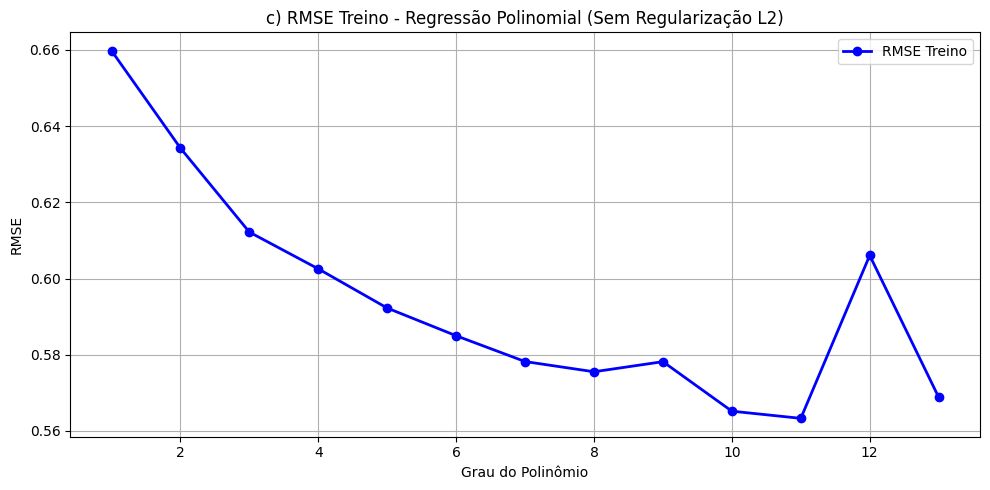

In [396]:
# Gráfico RMSE Treino - Sem Regularização
plt.figure(figsize=(10, 5))
plt.plot(degrees, rmse_train_no_reg, 'b-o', linewidth=2, markersize=6, label='RMSE Treino')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE')
plt.title('c) RMSE Treino - Regressão Polinomial (Sem Regularização L2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

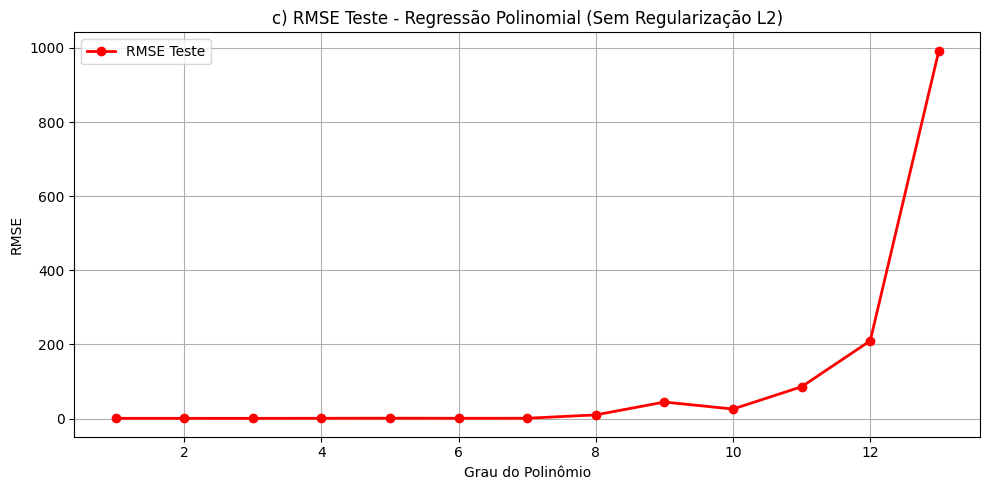

In [397]:
# Gráfico RMSE Teste - Sem Regularização
plt.figure(figsize=(10, 5))
plt.plot(degrees, rmse_test_no_reg, 'r-o', linewidth=2, markersize=6, label='RMSE Teste')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE')
plt.title('c) RMSE Teste - Regressão Polinomial (Sem Regularização L2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## d) Treinamento com Regularização L2 (λ = 0.01)

In [398]:
# Treinar 13 modelos com regularização L2 (lambda = 0.01)
lambda_reg = 0.01
rmse_train_l2 = []
rmse_test_l2 = []

print("d) Treinamento com Regularização L2 (λ = 0.01)")
print(f"{'Grau':<6} {'RMSE Treino':<15} {'RMSE Teste':<15}")

for degree in degrees:
    # Gerar features polinomiais
    X_train_poly = polynomial_features(X_train_norm, degree)
    X_test_poly = polynomial_features(X_test_norm, degree)
    
    # Treinar OLS com regularização L2
    w, y_pred_train_norm = ols_ridge(X_train_poly, y_train_norm, lambda_reg=lambda_reg)
    y_pred_test_norm = X_test_poly @ w
    
    # Desnormalizar predições
    y_pred_train = denormalize_zscore(y_pred_train_norm, y_params)
    y_pred_test = denormalize_zscore(y_pred_test_norm, y_params)
    
    # Calcular RMSE
    rmse_tr = float(rmse(y_train_raw, y_pred_train).item())
    rmse_te = float(rmse(y_test_raw, y_pred_test).item())
    
    rmse_train_l2.append(rmse_tr)
    rmse_test_l2.append(rmse_te)
    
    print(f"{degree:<6} {rmse_tr:<15.6f} {rmse_te:<15.6f}")

print()

d) Treinamento com Regularização L2 (λ = 0.01)
Grau   RMSE Treino     RMSE Teste     
1      0.659806        0.720768       
2      0.634623        0.710632       
3      0.619134        0.698727       
4      0.617210        0.693647       
5      0.616261        0.690718       
6      0.615509        0.689737       
7      0.614613        0.689641       
8      0.613475        0.689652       
9      0.612245        0.689474       
10     0.611155        0.689124       
11     0.610327        0.688707       
12     0.609762        0.688303       


13     0.609406        0.687954       



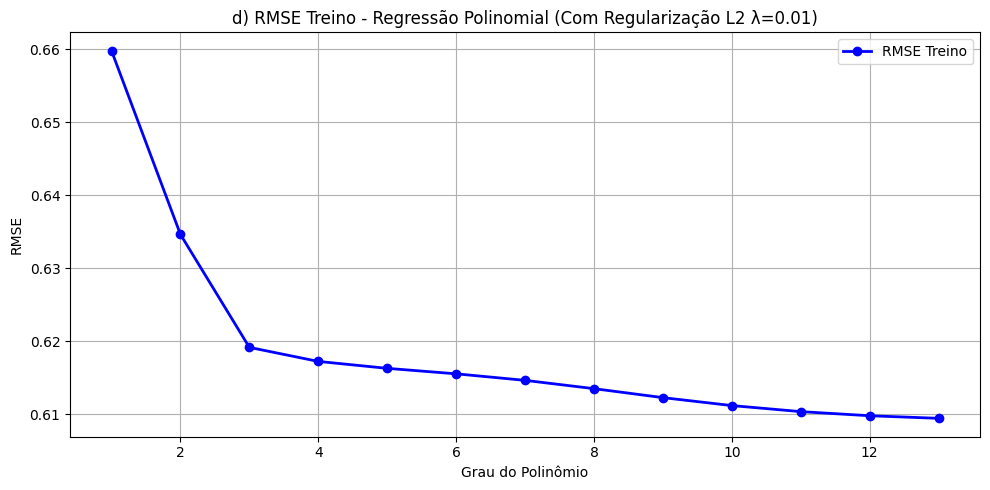

In [399]:
# Gráfico RMSE Treino - Com Regularização L2
plt.figure(figsize=(10, 5))
plt.plot(degrees, rmse_train_l2, 'b-o', linewidth=2, markersize=6, label='RMSE Treino')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE')
plt.title('d) RMSE Treino - Regressão Polinomial (Com Regularização L2 λ=0.01)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

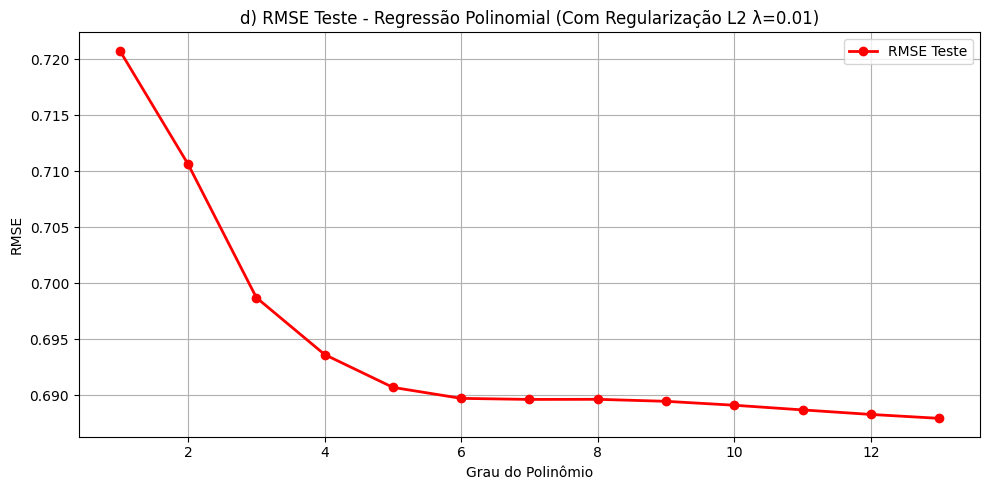

In [400]:
# Gráfico RMSE Teste - Com Regularização L2
plt.figure(figsize=(10, 5))
plt.plot(degrees, rmse_test_l2, 'r-o', linewidth=2, markersize=6, label='RMSE Teste')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE')
plt.title('d) RMSE Teste - Regressão Polinomial (Com Regularização L2 λ=0.01)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

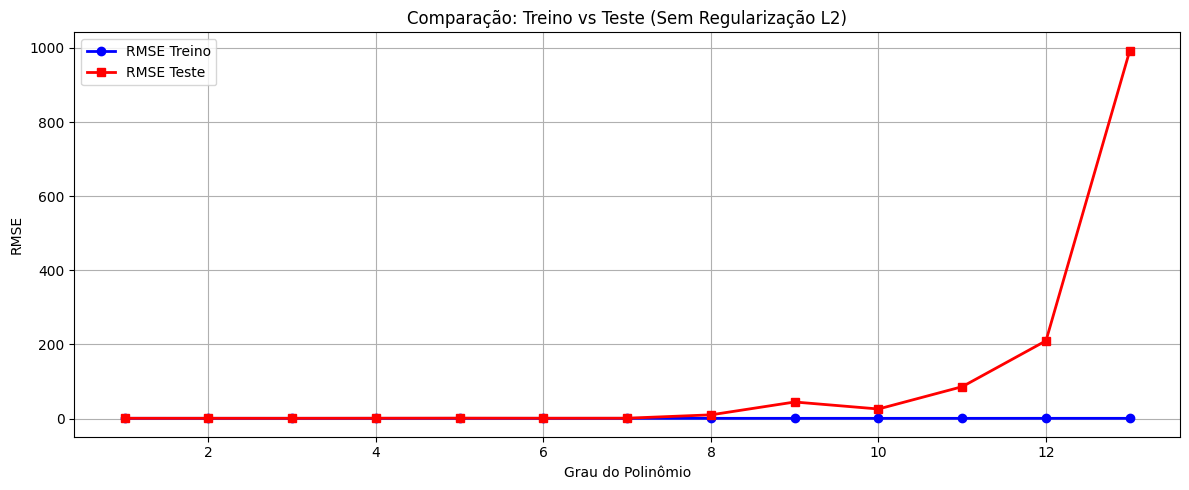

In [401]:
# Gráfico comparativo: Treino vs Teste (Sem Regularização)
plt.figure(figsize=(12, 5))
plt.plot(degrees, rmse_train_no_reg, 'b-o', linewidth=2, markersize=6, label='RMSE Treino')
plt.plot(degrees, rmse_test_no_reg, 'r-s', linewidth=2, markersize=6, label='RMSE Teste')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE')
plt.title('Comparação: Treino vs Teste (Sem Regularização L2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

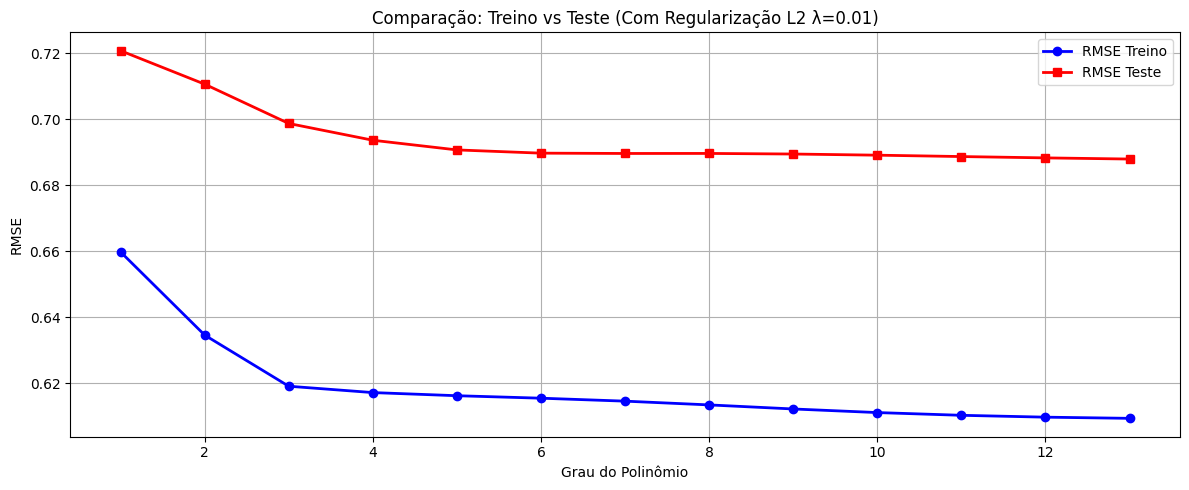

In [402]:
# Gráfico comparativo: Treino vs Teste (Com Regularização L2)
plt.figure(figsize=(12, 5))
plt.plot(degrees, rmse_train_l2, 'b-o', linewidth=2, markersize=6, label='RMSE Treino')
plt.plot(degrees, rmse_test_l2, 'r-s', linewidth=2, markersize=6, label='RMSE Teste')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE')
plt.title('Comparação: Treino vs Teste (Com Regularização L2 λ=0.01)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

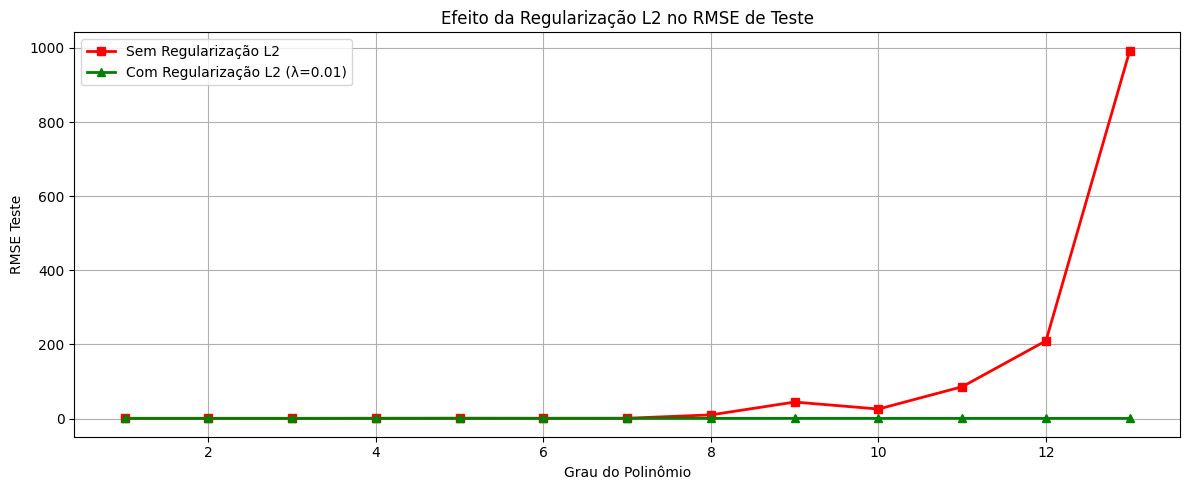

In [403]:
# Gráfico comparativo: Efeito da Regularização no Teste
plt.figure(figsize=(12, 5))
plt.plot(degrees, rmse_test_no_reg, 'r-s', linewidth=2, markersize=6, label='Sem Regularização L2')
plt.plot(degrees, rmse_test_l2, 'g-^', linewidth=2, markersize=6, label='Com Regularização L2 (λ=0.01)')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE Teste')
plt.title('Efeito da Regularização L2 no RMSE de Teste')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [404]:
print("\nResumo - Regularização L2")
for i, degree in enumerate(degrees):
    diff = rmse_test_no_reg[i] - rmse_test_l2[i]
    print(f"Grau {degree}: Sem Reg={rmse_test_no_reg[i]:.6f}, Com Reg={rmse_test_l2[i]:.6f}, Diff={diff:.6f}")



Resumo - Regularização L2
Grau 1: Sem Reg=0.720332, Com Reg=0.720768, Diff=-0.000437
Grau 2: Sem Reg=0.713453, Com Reg=0.710632, Diff=0.002821
Grau 3: Sem Reg=0.686427, Com Reg=0.698727, Diff=-0.012300
Grau 4: Sem Reg=0.870657, Com Reg=0.693647, Diff=0.177010
Grau 5: Sem Reg=1.049160, Com Reg=0.690718, Diff=0.358443
Grau 6: Sem Reg=0.877506, Com Reg=0.689737, Diff=0.187769
Grau 7: Sem Reg=0.925101, Com Reg=0.689641, Diff=0.235460
Grau 8: Sem Reg=10.009523, Com Reg=0.689652, Diff=9.319872
Grau 9: Sem Reg=44.666256, Com Reg=0.689474, Diff=43.976783
Grau 10: Sem Reg=25.793649, Com Reg=0.689124, Diff=25.104525
Grau 11: Sem Reg=85.989551, Com Reg=0.688707, Diff=85.300844
Grau 12: Sem Reg=209.874840, Com Reg=0.688303, Diff=209.186537
Grau 13: Sem Reg=992.587318, Com Reg=0.687954, Diff=991.899364
